In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('UMBF','FN'), 
         ('UMBF','KTOS'), 
         ('UMBF','MDGL'), 
         ('SPXC','FN'), 
         ('SPXC', 'KTOS'),
         ('SPXC', 'MDGL'), 
         ('DY','FN'), 
         ('DY', 'KTOS'), 
         ('DY','MDGL')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.1s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, 

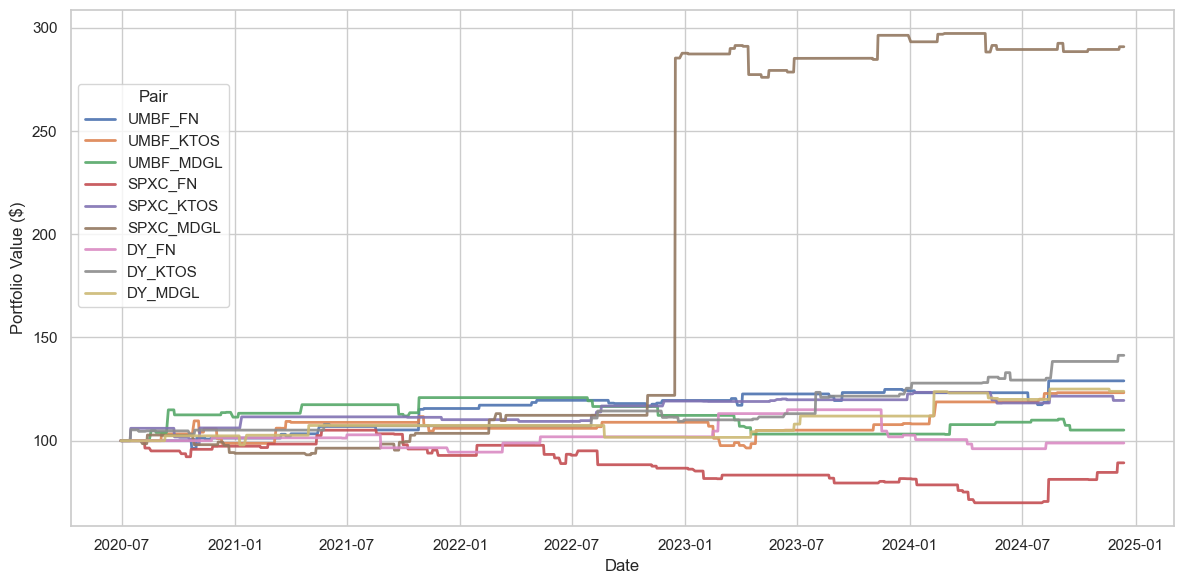

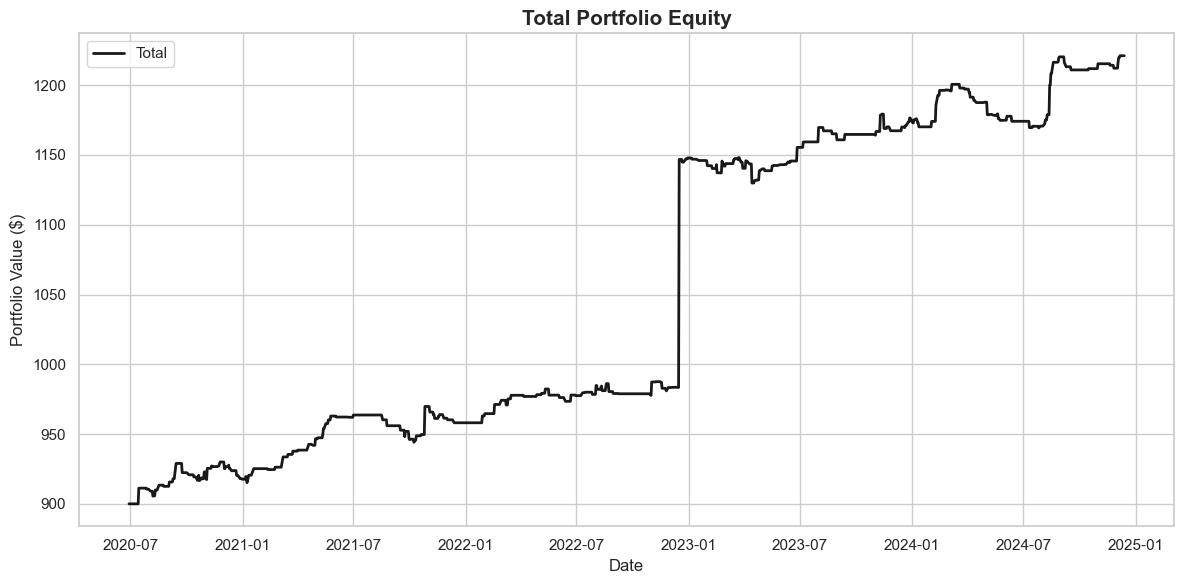

Summary
UMBF_FN: Final Value = $128.99, Total Return = 28.99%, Trades = 36
UMBF_KTOS: Final Value = $123.25, Total Return = 23.25%, Trades = 33
UMBF_MDGL: Final Value = $105.14, Total Return = 5.14%, Trades = 27
SPXC_FN: Final Value = $89.28, Total Return = -10.72%, Trades = 50
SPXC_KTOS: Final Value = $119.49, Total Return = 19.49%, Trades = 28
SPXC_MDGL: Final Value = $290.82, Total Return = 190.82%, Trades = 46
DY_FN: Final Value = $98.87, Total Return = -1.13%, Trades = 20
DY_KTOS: Final Value = $141.34, Total Return = 41.34%, Trades = 31
DY_MDGL: Final Value = $123.91, Total Return = 23.91%, Trades = 17

Total Portfolio Performance
Initial Portfolio Value: $900.00
Final Portfolio Value:   $1,221.10
Total Return:            35.68%

Sharpe Ratios
UMBF_FN: Sharpe Ratio = 0.74
UMBF_KTOS: Sharpe Ratio = 0.57
UMBF_MDGL: Sharpe Ratio = 0.18
SPXC_FN: Sharpe Ratio = -0.16
SPXC_KTOS: Sharpe Ratio = 0.63
SPXC_MDGL: Sharpe Ratio = 0.55
DY_FN: Sharpe Ratio = 0.01
DY_KTOS: Sharpe Ratio = 1.11
D

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)